In [1]:
!pip install tifffile
!pip install scikit-learn seaborn

In [2]:

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
EPOCHS = 20
DATA_DIR = "/kaggle/input/datasets/andrewmvd/malignant-lymphoma-classification"

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [4]:
full_dataset = ImageFolder(DATA_DIR)

NUM_CLASSES = len(full_dataset.classes)
print("Classes:", full_dataset.classes)

# Split 80-20
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply transforms separately
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Classes: ['CLL', 'FL', 'MCL']


In [5]:
def get_model(num_classes):
    model = models.densenet121(weights="IMAGENET1K_V1")

    # Freeze early layers
    for param in model.features[:5].parameters():
        param.requires_grad = False

    # Unfreeze rest
    for param in model.features[5:].parameters():
        param.requires_grad = True

    # Custom classifier
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.BatchNorm1d(512),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )

    return model

model = get_model(NUM_CLASSES).to(DEVICE)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 191MB/s]


In [6]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

criterion = FocalLoss()

In [7]:
optimizer = optim.AdamW([
    {"params": model.features[:5].parameters(), "lr": 1e-5},
    {"params": model.features[5:].parameters(), "lr": 1e-4},
    {"params": model.classifier.parameters(), "lr": 1e-3},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3)

In [8]:
def train_one_epoch():
    model.train()
    total_loss, correct = 0, 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    acc = correct / len(train_loader.dataset)
    return total_loss / len(train_loader), acc


def validate():
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

    acc = correct / len(val_loader.dataset)
    return total_loss / len(val_loader), acc

In [9]:
best_acc = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc = validate()

    scheduler.step(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "/kaggle/working/best_densenet.pth")
        print(" Saved Best Model")

print(" Best Val Accuracy:", best_acc)


Epoch 1/20


100%|██████████| 10/10 [00:08<00:00,  1.25it/s]


Train Loss: 0.5320 | Acc: 0.5719
Val   Loss: 0.6787 | Acc: 0.3067
 Saved Best Model

Epoch 2/20


100%|██████████| 10/10 [00:04<00:00,  2.33it/s]


Train Loss: 0.0987 | Acc: 0.9030
Val   Loss: 1.1559 | Acc: 0.3200
 Saved Best Model

Epoch 3/20


...

Train Loss: 0.0016 | Acc: 1.0000
Val   Loss: 0.1681 | Acc: 0.8267

Epoch 19/20


100%|██████████| 10/10 [00:04<00:00,  2.30it/s]


Train Loss: 0.0017 | Acc: 1.0000
Val   Loss: 0.1663 | Acc: 0.8267

Epoch 20/20


100%|██████████| 10/10 [00:04<00:00,  2.50it/s]


Train Loss: 0.0014 | Acc: 1.0000
Val   Loss: 0.1789 | Acc: 0.8400
 Best Val Accuracy: 0.84


In [10]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, loader, class_names):
    model.eval()
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # =========================
    # Classification Report
    # =========================
    print("\n📊 Classification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # =========================
    # Confusion Matrix
    # =========================
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    return cm


📊 Classification Report:

              precision    recall  f1-score   support

         CLL       0.87      0.80      0.83        25
          FL       0.90      0.90      0.90        29
         MCL       0.74      0.81      0.77        21

    accuracy                           0.84        75
   macro avg       0.84      0.84      0.83        75
weighted avg       0.84      0.84      0.84        75



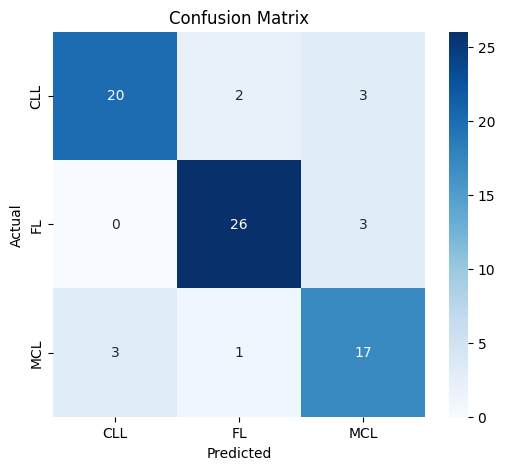

In [11]:
class_names = full_dataset.classes  # ['CLL', 'FL', 'MCL']

cm = evaluate_model(model, val_loader, class_names)

In [12]:
def per_class_accuracy(cm, class_names):
    print("\n📌 Per-Class Accuracy:\n")
    for i, class_name in enumerate(class_names):
        acc = cm[i,i] / cm[i].sum()
        print(f"{class_name}: {acc:.4f}")

per_class_accuracy(cm, class_names)


📌 Per-Class Accuracy:

CLL: 0.8000
FL: 0.8966
MCL: 0.8095
